# NIRIKSHAK-AI — CICMalDroid 2020 XGBoost Training

**Member A: AI & Machine Learning Engine**

Goal of this notebook:

1. Locate and load the CICMalDroid 2020 470-feature CSV on Kaggle.
2. Detect the target/class column safely.
3. Convert the 5-category dataset into the binary task required by NIRIKSHAK-AI:
   - `Benign -> 0`
   - `Any malware category -> 1`
4. Train an XGBoost classifier.
5. Evaluate it using classification and probability metrics.
6. Export:
   - `xgb_cicmaldroid.json`
   - `xgb_cicmaldroid_metadata.json`
7. Reload the exported model and run a smoke test.

The exported model probability for class `1` is the runtime quantity **PML** used by NIRIKSHAK-AI.


## 0. Kaggle setup

Attach the CICMalDroid 2020 dataset to this notebook using **Add Input**.

This notebook intentionally does **not** hard-code a Kaggle input directory. It searches `/kaggle/input` for the expected CICMalDroid CSV.


In [4]:
# Cell 1 — Imports and reproducibility

import os
import re
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

import xgboost as xgb

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("pandas:", pd.__version__)
print("xgboost:", xgb.__version__)


pandas: 2.3.3
xgboost: 3.2.0


In [5]:
# Cell 2 — Discover files attached to the Kaggle notebook

INPUT_ROOT = Path("/kaggle/input/datasets/hasanccr92/cicmaldroid-2020")

all_files = [p for p in INPUT_ROOT.rglob("*") if p.is_file()]

print(f"Total attached files: {len(all_files):,}")
for p in all_files[:100]:
    print(p)

if not all_files:
    raise FileNotFoundError(
        "No files found under /kaggle/input. Use Kaggle's 'Add Input' button "
        "to attach the CICMalDroid 2020 dataset."
    )


Total attached files: 1
/kaggle/input/datasets/hasanccr92/cicmaldroid-2020/feature_vectors_syscallsbinders_frequency_5_Cat.csv


In [6]:
# Cell 3 — Locate the CICMalDroid 470-feature CSV

csv_files = [p for p in all_files if p.suffix.lower() == ".csv"]

print("\nCSV files found:")
for p in csv_files:
    print(" -", p)

# Prefer the known CICMalDroid 470-feature filename.
preferred_tokens = [
    "feature_vectors_syscallsbinders_frequency_5_cat",
    "syscallsbinders",
    "frequency_5_cat",
]

def score_path(path):
    name = path.name.lower()
    score = 0
    for i, token in enumerate(preferred_tokens):
        if token in name:
            score += (len(preferred_tokens) - i) * 10
    return score

ranked_csvs = sorted(csv_files, key=score_path, reverse=True)

if not ranked_csvs:
    raise FileNotFoundError("No CSV file found in the attached Kaggle dataset.")

DATA_PATH = ranked_csvs[0]

print("\nSelected CSV:")
print(DATA_PATH)



CSV files found:
 - /kaggle/input/datasets/hasanccr92/cicmaldroid-2020/feature_vectors_syscallsbinders_frequency_5_Cat.csv

Selected CSV:
/kaggle/input/datasets/hasanccr92/cicmaldroid-2020/feature_vectors_syscallsbinders_frequency_5_Cat.csv


In [7]:
# Cell 4 — Load the dataset

df = pd.read_csv(DATA_PATH, low_memory=False)

print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

print("\nFirst 10 column names:")
print(df.columns[:10].tolist())

print("\nLast 10 column names:")
print(df.columns[-10:].tolist())


Shape: (11598, 471)
Rows: 11598
Columns: 471


,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,utimes,vfork,vibrate,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev,Class
0,1,0,0,3,0,14,2,0,3,0,...,0,0,0,0,0,0,0,37,10,1
1,3,0,0,6,0,42,91,0,32,0,...,0,0,0,0,0,0,2,2838,46,1
2,2,0,0,4,0,23,3,0,17,2,...,0,0,0,0,0,0,1,111,20,1
3,1,0,0,4,0,27,9,0,36,0,...,0,0,0,0,0,0,7,987,197,1
4,3,0,0,11,0,18,3,0,16,0,...,0,0,0,0,0,0,1,98,25,1



First 10 column names:
['ACCESS_PERSONAL_INFO___', 'ALTER_PHONE_STATE___', 'ANTI_DEBUG_____', 'CREATE_FOLDER_____', 'CREATE_PROCESS`_____', 'CREATE_THREAD_____', 'DEVICE_ACCESS_____', 'EXECUTE_____', 'FS_ACCESS____', 'FS_ACCESS()____']

Last 10 column names:
['utimes', 'vfork', 'vibrate', 'vibratePattern', 'wait4', 'watchRotation', 'windowGainedFocus', 'write', 'writev', 'Class']


In [8]:
# Cell 5 — Detect the target/class column

# The notebook first looks for conventional target names.
normalized_to_original = {
    re.sub(r"[^a-z0-9]", "", str(c).lower()): c
    for c in df.columns
}

target_name_candidates = [
    "class",
    "category",
    "label",
    "target",
    "malwareclass",
    "malwarecategory",
]

TARGET_COL = None

for candidate in target_name_candidates:
    normalized = re.sub(r"[^a-z0-9]", "", candidate.lower())
    if normalized in normalized_to_original:
        TARGET_COL = normalized_to_original[normalized]
        break

# Safe fallback: CIC-style feature files commonly place the class/category at the end.
if TARGET_COL is None:
    last_col = df.columns[-1]
    nunique_last = df[last_col].nunique(dropna=False)

    if nunique_last <= 20:
        TARGET_COL = last_col
        print(
            f"No conventional target name found. "
            f"Using final column '{TARGET_COL}' because it has only {nunique_last} unique values."
        )
    else:
        raise ValueError(
            "Could not identify the target column automatically. "
            "Set TARGET_COL manually after inspecting df.columns."
        )

print("TARGET_COL =", TARGET_COL)
print("dtype      =", df[TARGET_COL].dtype)
print("unique     =", df[TARGET_COL].unique())
print("\nValue counts:")
display(df[TARGET_COL].value_counts(dropna=False).to_frame("count"))


TARGET_COL = Class
dtype      = int64
unique     = [1 2 3 4 5]

Value counts:


,count
Class,
3,3904
4,2546
2,2100
5,1795
1,1253


In [9]:
# Cell 6 — Basic data-quality audit

print("Dataset shape:", df.shape)
print("Duplicate rows:", int(df.duplicated().sum()))
print("Total missing cells:", int(df.isna().sum().sum()))

missing_by_col = df.isna().sum().sort_values(ascending=False)
print("\nColumns with missing values:")
display(missing_by_col[missing_by_col > 0].head(30).to_frame("missing"))

print("\nTarget missing values:", int(df[TARGET_COL].isna().sum()))


Dataset shape: (11598, 471)
Duplicate rows: 72
Total missing cells: 0

Columns with missing values:


,missing



Target missing values: 0


## 1. Define the binary target

NIRIKSHAK-AI ultimately needs:

`PML = probability that the analyzed application is malicious`.

Therefore this notebook trains:

- **0 = Benign**
- **1 = Malware**

The original CICMalDroid family/category is kept only for auditing.

The official CICMalDroid 2020 dataset contains five categories. If the target values are strings, the notebook auto-detects `Benign`. If the target is numeric, it only auto-detects the benign code when the raw file exactly matches the official 11,598-row category counts; otherwise it stops and asks you to set `BENIGN_RAW_LABEL` manually instead of guessing.


In [10]:
# Cell 7 — Identify which raw label means Benign

raw_counts = df[TARGET_COL].value_counts(dropna=False)

BENIGN_RAW_LABEL = None

# 1) Best case: label itself contains the word "benign".
for raw_label in raw_counts.index:
    if "benign" in str(raw_label).strip().lower():
        BENIGN_RAW_LABEL = raw_label
        break

# 2) Conservative fallback for the original unmodified 11,598-sample CICMalDroid file:
# official count for Benign = 1,795.
if BENIGN_RAW_LABEL is None and len(raw_counts) == 5 and len(df) == 11598:
    candidates = raw_counts[raw_counts == 1795].index.tolist()
    if len(candidates) == 1:
        BENIGN_RAW_LABEL = candidates[0]
        print(
            "Benign label was inferred from the official CICMalDroid 2020 "
            "count of 1,795 benign samples."
        )

print("Detected BENIGN_RAW_LABEL =", BENIGN_RAW_LABEL)

if BENIGN_RAW_LABEL is None:
    print("\nRaw labels and counts:")
    display(raw_counts.to_frame("count"))
    raise ValueError(
        "The benign raw label could not be determined safely. "
        "Set BENIGN_RAW_LABEL manually in this cell to the exact raw value that means Benign, "
        "then rerun from this cell onward."
    )


Benign label was inferred from the official CICMalDroid 2020 count of 1,795 benign samples.
Detected BENIGN_RAW_LABEL = 5


In [11]:
# Cell 8 — Build y: Benign=0, Malware=1

work_df = df.copy()

# Remove rows with missing target, if any.
work_df = work_df[work_df[TARGET_COL].notna()].copy()

y = (work_df[TARGET_COL] != BENIGN_RAW_LABEL).astype(int)

print("Binary target distribution:")
binary_counts = y.value_counts().sort_index()
binary_counts.index = ["Benign (0)", "Malware (1)"]
display(binary_counts.to_frame("count"))

print("\nMalware fraction:", round(float(y.mean()), 4))


Binary target distribution:


,count
Benign (0),1795
Malware (1),9803



Malware fraction: 0.8452


## 2. Prepare the 470 CICMalDroid behavioral features

The CSV contains frequency/count features derived from system calls, Binder activity, and composite behaviors.

For XGBoost:

- no `StandardScaler` or `MinMaxScaler` is needed;
- raw count scales are acceptable;
- non-numeric artifacts are coerced safely;
- missing/infinite values are replaced with training medians;
- constant columns are removed;
- model-facing columns are renamed `f0, f1, ...` to avoid XGBoost feature-name restrictions;
- the original feature order and medians are saved to metadata for runtime inference.


In [12]:
# Cell 9 — Separate X from the target and remove obvious non-feature index columns

X_raw = work_df.drop(columns=[TARGET_COL]).copy()

# Drop accidental CSV index columns such as "Unnamed: 0".
index_like_cols = [
    c for c in X_raw.columns
    if str(c).lower().startswith("unnamed:")
]

if index_like_cols:
    print("Dropping index-like columns:", index_like_cols)
    X_raw = X_raw.drop(columns=index_like_cols)

print("Raw feature count:", X_raw.shape[1])


Raw feature count: 470


In [13]:
# Cell 10 — Convert feature matrix to numeric

X_numeric = X_raw.apply(pd.to_numeric, errors="coerce")
X_numeric = X_numeric.replace([np.inf, -np.inf], np.nan)

# Remove columns that are entirely missing/non-numeric.
all_nan_cols = X_numeric.columns[X_numeric.isna().all()].tolist()
if all_nan_cols:
    print(f"Dropping {len(all_nan_cols)} all-NaN/non-numeric columns.")
    X_numeric = X_numeric.drop(columns=all_nan_cols)

# Remove constant columns.
nunique = X_numeric.nunique(dropna=False)
constant_cols = nunique[nunique <= 1].index.tolist()

if constant_cols:
    print(f"Dropping {len(constant_cols)} constant columns.")
    X_numeric = X_numeric.drop(columns=constant_cols)

print("Usable feature count:", X_numeric.shape[1])

# Keep original feature names/order for runtime mapping.
ORIGINAL_FEATURE_NAMES = X_numeric.columns.tolist()

# Rename to safe model-facing names.
MODEL_FEATURE_NAMES = [f"f{i}" for i in range(len(ORIGINAL_FEATURE_NAMES))]
original_to_model = dict(zip(ORIGINAL_FEATURE_NAMES, MODEL_FEATURE_NAMES))

X_numeric.columns = MODEL_FEATURE_NAMES

display(X_numeric.head())


Usable feature count: 470


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f460,f461,f462,f463,f464,f465,f466,f467,f468,f469
0,1,0,0,3,0,14,2,0,3,0,...,0,0,0,0,0,0,0,0,37,10
1,3,0,0,6,0,42,91,0,32,0,...,0,0,0,0,0,0,0,2,2838,46
2,2,0,0,4,0,23,3,0,17,2,...,0,0,0,0,0,0,0,1,111,20
3,1,0,0,4,0,27,9,0,36,0,...,0,0,0,0,0,0,0,7,987,197
4,3,0,0,11,0,18,3,0,16,0,...,0,0,0,0,0,0,0,1,98,25


In [14]:
# Cell 11 — Train/test split BEFORE fitting imputations

X_train, X_test, y_train, y_test = train_test_split(
    X_numeric,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train malware fraction:", round(float(y_train.mean()), 4))
print("y_test  malware fraction:", round(float(y_test.mean()), 4))


X_train: (9278, 470)
X_test : (2320, 470)
y_train malware fraction: 0.8452
y_test  malware fraction: 0.8453


In [15]:
# Cell 12 — Median imputation learned only from training data

train_medians = X_train.median(axis=0)

# For any pathological feature whose median is still NaN, use zero.
train_medians = train_medians.fillna(0.0)

X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

print("Imputation complete.")


Imputation complete.


## 3. Train XGBoost

This is a strong, reproducible baseline rather than an exhaustive hyperparameter search.

The model uses `binary:logistic`, so `predict_proba(... )[:, 1]` directly gives **PML**.


In [16]:
# Cell 13 — Train XGBoost binary classifier

model = xgb.XGBClassifier(
    objective="binary:logistic",
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    min_child_weight=1,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.0,
    reg_lambda=1.0,
    gamma=0.0,
    tree_method="hist",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False,
)

print("Training complete.")


Training complete.


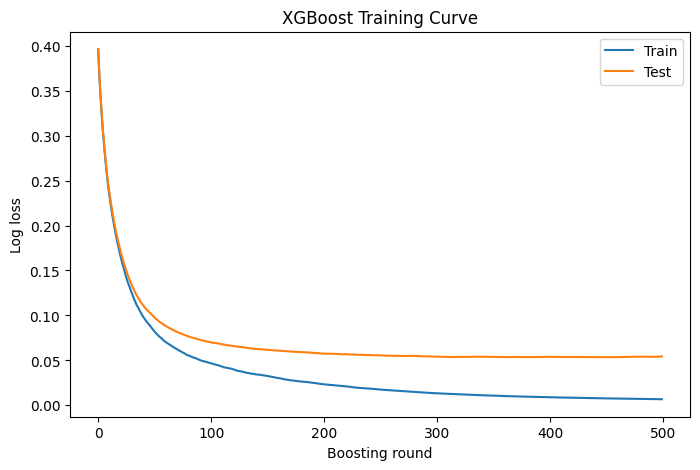

In [17]:
# Cell 14 — Plot training/test log loss

evals = model.evals_result()

plt.figure(figsize=(8, 5))
plt.plot(evals["validation_0"]["logloss"], label="Train")
plt.plot(evals["validation_1"]["logloss"], label="Test")
plt.xlabel("Boosting round")
plt.ylabel("Log loss")
plt.title("XGBoost Training Curve")
plt.legend()
plt.show()


## 4. Evaluate the model

Because the dataset is imbalanced, do not judge the model from accuracy alone.

Report:

- Accuracy
- Balanced accuracy
- Precision
- Recall
- F1
- ROC-AUC
- PR-AUC
- Confusion matrix
- Classification report


In [18]:
# Cell 15 — Predictions and headline metrics

p_ml = model.predict_proba(X_test)[:, 1]
y_pred = (p_ml >= 0.50).astype(int)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "precision_malware": precision_score(y_test, y_pred, zero_division=0),
    "recall_malware": recall_score(y_test, y_pred, zero_division=0),
    "f1_malware": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, p_ml),
    "pr_auc": average_precision_score(y_test, p_ml),
}

metrics_df = pd.DataFrame(
    {"metric": metrics.keys(), "value": metrics.values()}
)

display(metrics_df)


,metric,value
0,accuracy,0.981034
1,balanced_accuracy,0.952372
2,precision_malware,0.983847
3,recall_malware,0.993881
4,f1_malware,0.988838
5,roc_auc,0.996656
6,pr_auc,0.999377


In [19]:
# Cell 16 — Classification report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Malware"],
        digits=4,
        zero_division=0,
    )
)


              precision    recall  f1-score   support

      Benign     0.9646    0.9109    0.9370       359
     Malware     0.9838    0.9939    0.9888      1961

    accuracy                         0.9810      2320
   macro avg     0.9742    0.9524    0.9629      2320
weighted avg     0.9809    0.9810    0.9808      2320



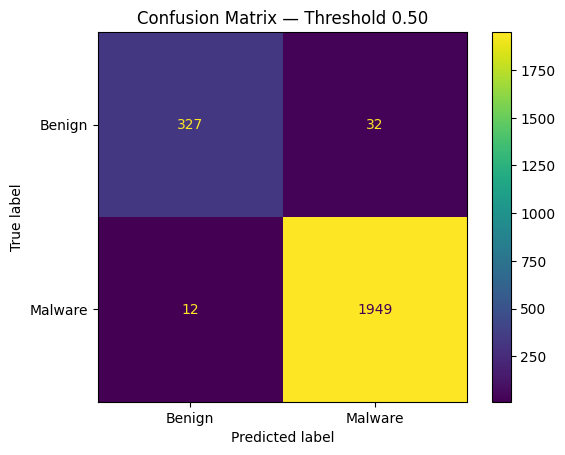

In [20]:
# Cell 17 — Confusion matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malware"],
)

disp.plot(values_format="d")
plt.title("Confusion Matrix — Threshold 0.50")
plt.show()


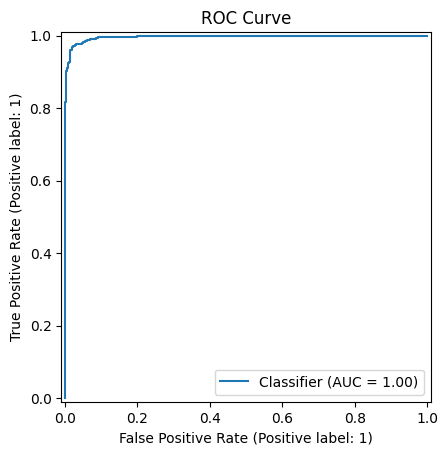

In [21]:
# Cell 18 — ROC curve

RocCurveDisplay.from_predictions(y_test, p_ml)
plt.title("ROC Curve")
plt.show()


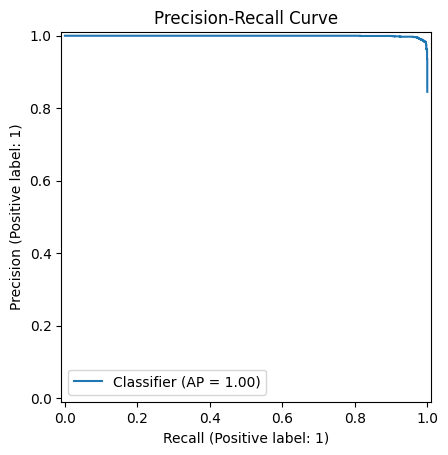

In [22]:
# Cell 19 — Precision-recall curve

PrecisionRecallDisplay.from_predictions(y_test, p_ml)
plt.title("Precision-Recall Curve")
plt.show()


In [23]:
# Cell 20 — Threshold comparison

threshold_rows = []

for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    pred_t = (p_ml >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_test, pred_t, zero_division=0),
        "recall": recall_score(y_test, pred_t, zero_division=0),
        "f1": f1_score(y_test, pred_t, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred_t),
        "false_negatives": int(((y_test.to_numpy() == 1) & (pred_t == 0)).sum()),
        "false_positives": int(((y_test.to_numpy() == 0) & (pred_t == 1)).sum()),
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)


,threshold,precision,recall,f1,balanced_accuracy,false_negatives,false_positives
0,0.3,0.979449,0.996430,0.987867,0.941112,7,41
1,0.4,0.981900,0.995920,0.988861,0.947821,8,36
2,0.5,0.983847,0.993881,0.988838,0.952372,12,32
3,0.6,0.984312,0.991841,0.988062,0.952745,16,31
4,0.7,0.985780,0.989801,0.987786,0.955903,20,28


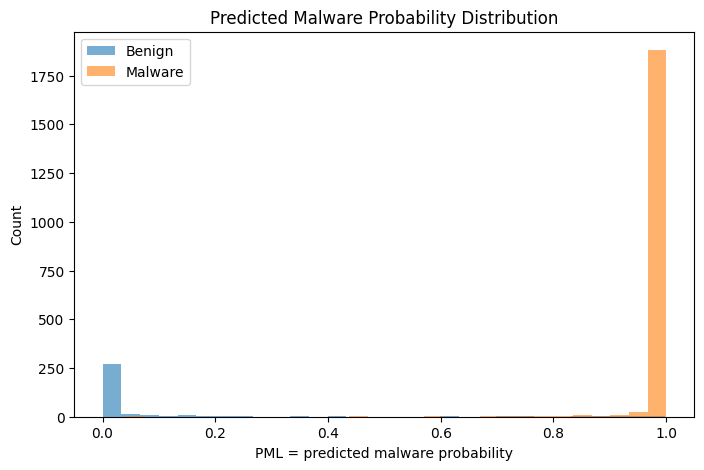

In [24]:
# Cell 21 — Distribution of PML

plt.figure(figsize=(8, 5))
plt.hist(p_ml[y_test.to_numpy() == 0], bins=30, alpha=0.6, label="Benign")
plt.hist(p_ml[y_test.to_numpy() == 1], bins=30, alpha=0.6, label="Malware")
plt.xlabel("PML = predicted malware probability")
plt.ylabel("Count")
plt.title("Predicted Malware Probability Distribution")
plt.legend()
plt.show()


## 5. Inspect feature importance

This is useful for sanity checking the trained model, but feature importance alone should not be interpreted as a causal explanation of malware behavior.


,model_feature,original_feature,importance
168,f168,getInstallerPackageName,0.314942
38,f38,_newselect,0.044493
358,f358,resolveIntent,0.039854
13,f13,FS_ACCESS(CREATE__READ__WRITE),0.038633
280,f280,isSpeakerphoneOn,0.020272
0,f0,ACCESS_PERSONAL_INFO___,0.017737
213,f213,getSubscriberId,0.017365
7,f7,EXECUTE_____,0.017319
179,f179,getMode,0.016906
173,f173,getLine1Number,0.014457


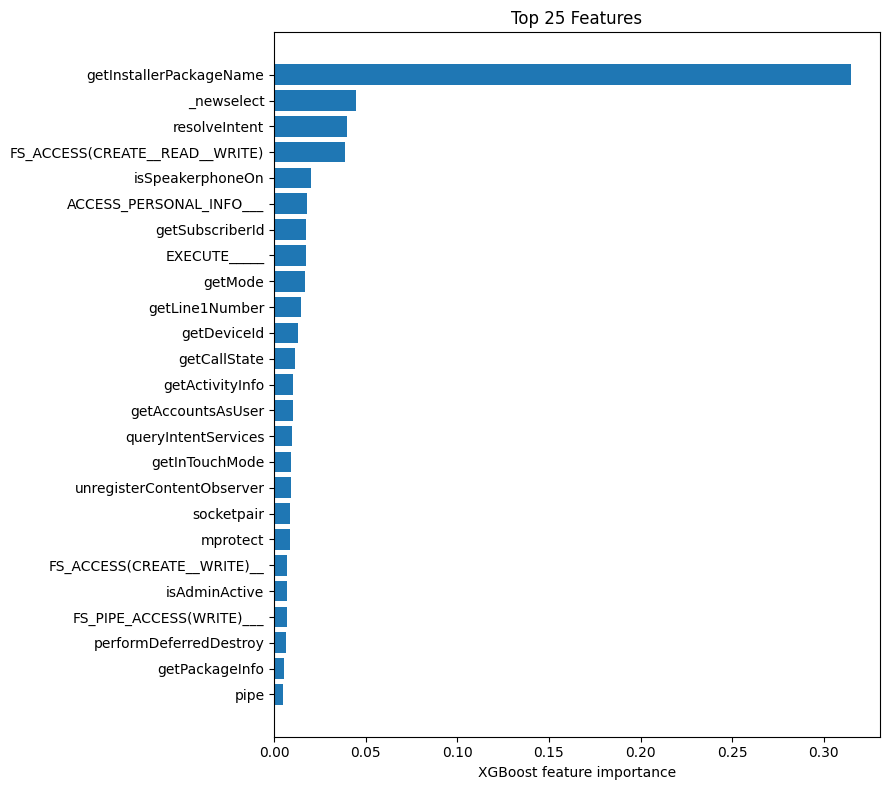

In [25]:
# Cell 22 — Top feature importances

importance = model.feature_importances_

importance_df = pd.DataFrame({
    "model_feature": MODEL_FEATURE_NAMES,
    "original_feature": ORIGINAL_FEATURE_NAMES,
    "importance": importance,
}).sort_values("importance", ascending=False)

display(importance_df.head(30))

top_n = 25
plot_df = importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(9, 8))
plt.barh(plot_df["original_feature"], plot_df["importance"])
plt.xlabel("XGBoost feature importance")
plt.title(f"Top {top_n} Features")
plt.tight_layout()
plt.show()


## 6. Export model + runtime metadata

The project requires the trained lightweight XGBoost weights as:

`ai_engine/models/xgb_cicmaldroid.json`

This notebook also writes a small metadata JSON. The metadata is important because the runtime must reconstruct the exact feature order used during training.


In [26]:
# Cell 23 — Save model and metadata

OUTPUT_DIR = Path("/kaggle/working")
MODEL_PATH = OUTPUT_DIR / "xgb_cicmaldroid.json"
METADATA_PATH = OUTPUT_DIR / "xgb_cicmaldroid_metadata.json"
METRICS_PATH = OUTPUT_DIR / "xgb_cicmaldroid_metrics.json"

model.save_model(MODEL_PATH)

# Convert medians back to original feature names.
model_medians = train_medians.to_dict()
original_medians = {
    original_name: float(model_medians[model_name])
    for original_name, model_name in original_to_model.items()
}

metadata = {
    "dataset": "CICMalDroid 2020",
    "source_csv": DATA_PATH.name,
    "target_column": str(TARGET_COL),
    "task": "binary_malware_detection",
    "negative_class": "Benign",
    "positive_class": "Malware",
    "benign_raw_label": str(BENIGN_RAW_LABEL),
    "pml_definition": "predict_proba(X)[:, 1]",
    "decision_threshold_default": 0.50,
    "random_state": RANDOM_STATE,
    "training_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "feature_count": int(len(ORIGINAL_FEATURE_NAMES)),
    "feature_names_original": [str(x) for x in ORIGINAL_FEATURE_NAMES],
    "feature_names_model": MODEL_FEATURE_NAMES,
    "original_to_model_feature": {
        str(k): str(v) for k, v in original_to_model.items()
    },
    "training_feature_medians": original_medians,
    "dropped_index_like_columns": [str(x) for x in index_like_cols],
    "dropped_all_nan_columns": [str(x) for x in all_nan_cols],
    "dropped_constant_columns": [str(x) for x in constant_cols],
}

with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

with open(METRICS_PATH, "w") as f:
    json.dump({k: float(v) for k, v in metrics.items()}, f, indent=2)

print("Saved:")
print(" -", MODEL_PATH)
print(" -", METADATA_PATH)
print(" -", METRICS_PATH)


Saved:
 - /kaggle/working/xgb_cicmaldroid.json
 - /kaggle/working/xgb_cicmaldroid_metadata.json
 - /kaggle/working/xgb_cicmaldroid_metrics.json


## 7. Reload smoke test

Never trust an exported model until you load it again and verify that its predictions match the original model.


In [27]:
# Cell 24 — Reload exported XGBoost model

reloaded_model = xgb.XGBClassifier()
reloaded_model.load_model(MODEL_PATH)

original_probs = model.predict_proba(X_test.iloc[:25])[:, 1]
reloaded_probs = reloaded_model.predict_proba(X_test.iloc[:25])[:, 1]

max_abs_diff = np.max(np.abs(original_probs - reloaded_probs))

print("Maximum probability difference:", max_abs_diff)

assert np.allclose(original_probs, reloaded_probs, atol=1e-7)

print("Reload test PASSED.")


Maximum probability difference: 0.0
Reload test PASSED.


## 8. Runtime-style PML inference smoke test

At inference time, NIRIKSHAK-AI must provide the same CICMalDroid features in the same order.

The helper below demonstrates the expected contract:

`dictionary of original CICMalDroid feature counts -> PML in [0, 1]`

Missing runtime features are filled with training medians for robustness. In the final application, however, a high number of missing features should be surfaced as a data-quality warning rather than silently treated as equivalent to a complete dynamic analysis.


In [28]:
# Cell 25 — Runtime-style inference helper

with open(METADATA_PATH, "r") as f:
    runtime_meta = json.load(f)

runtime_original_features = runtime_meta["feature_names_original"]
runtime_model_features = runtime_meta["feature_names_model"]
runtime_medians = runtime_meta["training_feature_medians"]

def predict_pml_from_feature_dict(feature_dict, fitted_model=reloaded_model):
    values = []

    for original_name in runtime_original_features:
        value = feature_dict.get(
            original_name,
            runtime_medians[original_name],
        )

        try:
            value = float(value)
            if not np.isfinite(value):
                value = float(runtime_medians[original_name])
        except Exception:
            value = float(runtime_medians[original_name])

        values.append(value)

    row = pd.DataFrame(
        [values],
        columns=runtime_model_features,
    )

    p_ml_value = float(fitted_model.predict_proba(row)[0, 1])
    return p_ml_value

# Use one real test row to verify the helper.
sample_idx = X_test.index[0]

# Reconstruct a dictionary with original feature names.
sample_model_row = X_numeric.loc[sample_idx]
sample_feature_dict = {
    original_name: float(sample_model_row[model_name])
    for original_name, model_name in original_to_model.items()
}

sample_pml = predict_pml_from_feature_dict(sample_feature_dict)

print("Sample PML:", sample_pml)
assert 0.0 <= sample_pml <= 1.0


Sample PML: 0.993355393409729


In [29]:
# Cell 26 — Save test predictions for later inspection

predictions_df = pd.DataFrame({
    "y_true": y_test.to_numpy(),
    "p_ml": p_ml,
    "y_pred_0_50": y_pred,
})

PREDICTIONS_PATH = OUTPUT_DIR / "cicmaldroid_test_predictions.csv"
predictions_df.to_csv(PREDICTIONS_PATH, index=False)

print("Saved:", PREDICTIONS_PATH)
display(predictions_df.head())


Saved: /kaggle/working/cicmaldroid_test_predictions.csv


,y_true,p_ml,y_pred_0_50
0,1,0.993355,1
1,1,0.997212,1
2,1,0.998360,1
3,1,0.999993,1
4,1,0.999316,1


## 9. Final outputs

After all cells pass, download these files from the Kaggle **Output** panel:

- `xgb_cicmaldroid.json` — commit to `ai_engine/models/`
- `xgb_cicmaldroid_metadata.json` — recommended companion metadata for exact runtime feature reconstruction
- `xgb_cicmaldroid_metrics.json` — optional experiment record
- `cicmaldroid_test_predictions.csv` — optional local evaluation artifact; do not need to commit it

Also use **Save Version** in Kaggle and download the notebook itself as:

`train_xgboost.ipynb`

Then place it in:

`ai_engine/training_notebooks/train_xgboost.ipynb`

Do **not** commit the CICMalDroid dataset to GitHub.
